Fundamentals of Dynamics and Controls HW5

In [4]:
# imports
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import DynCon_Functions as df
from numpy import sin, cos, pi

Problem 1

Part a

Eigen Values:
 [24.05049866 15.1966757  12.75282563]
Eigen Vectors:
 [[ 0.45445938 -0.88494078 -0.10171765]
 [-0.77326598 -0.44861618  0.44811076]
 [ 0.44218367  0.12499334  0.88817243]]
Principal Inertial Matrix:
 [[24.0505  0.      0.    ]
 [ 0.     15.1967  0.    ]
 [ 0.      0.     12.7528]]
Part b

Quaternion:
 [ 0.08409873  0.14156282 -0.02906593  0.98592218]


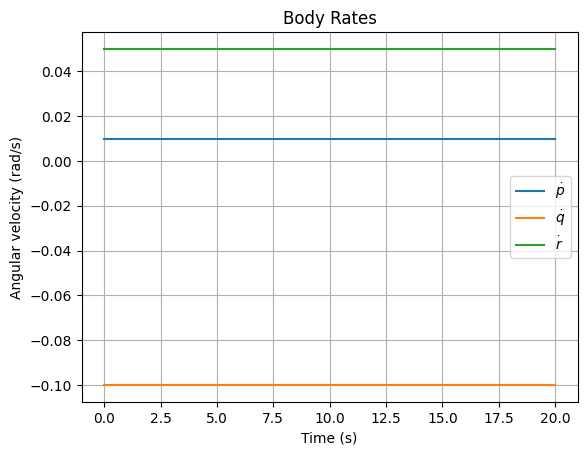

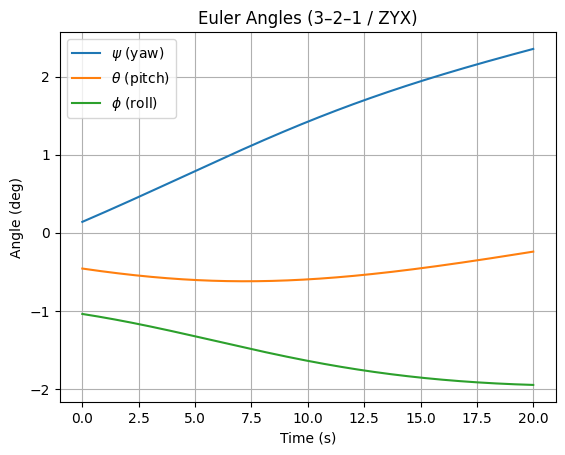

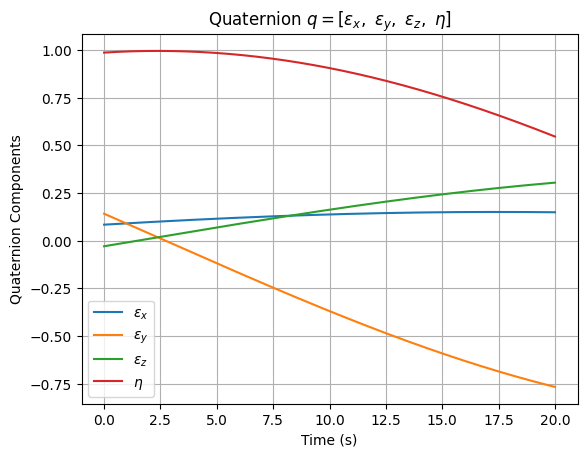

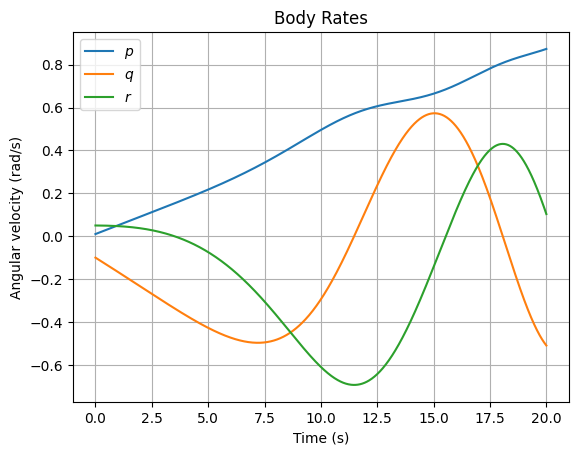

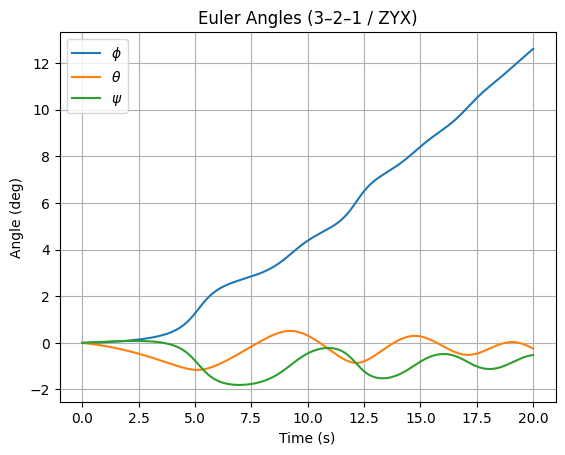

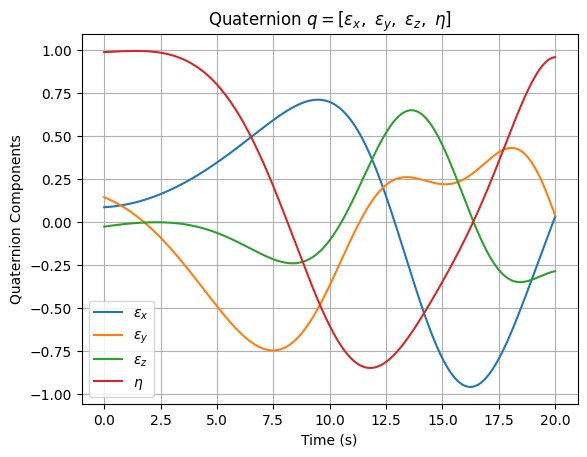

In [ ]:
# constants
J = np.array([[17, -3,  2],
              [-3, 20, -4],
              [ 2, -4, 15]])
wb0 = np.array([.01, -.1, .05], dtype=float)
eulervals = np.array([0, 0, 0], dtype=float)
t0 = 0
tf = 20
t_eval = np.linspace(t0, tf, 1001)


# part a
print("Part a\n")
eigenvalues, eigenvectors = np.linalg.eig(J)
C_bo = eigenvectors
I = np.round(C_bo.T @ J @ C_bo,4)
print(f"Eigen Values:\n {eigenvalues}\nEigen Vectors:\n {eigenvectors}")
print(f"Principal Inertial Matrix:\n {I}")

# part b
print("Part b\n")
euler = df.rotm_to_euler321(C_bo)
q0 = np.zeros(4)
q0[3] = np.sqrt((np.trace(C_bo) + 1)/2)
q0[2] = (C_bo[0,1] - C_bo[1,0]) / (4*q0[3])
q0[1] = (C_bo[2,0] - C_bo[0,2]) / (4*q0[3])
q0[0] = (C_bo[1,2] - C_bo[2,1]) / (4*q0[3])
q0 = q0 / np.linalg.norm(q0)
print(f"Quaternion:\n {q0}")
y0 = np.hstack((euler, q0))
sol = solve_ivp(
    lambda t, y: df.angvel_to_quateuler(t, y, wb0),
    (t0, tf),
    y0,
    t_eval=t_eval,
    rtol=1e-9, atol=1e-12, method='RK45'
)

t = sol.t
phi, theta, psi, eps1, eps2, eps3, eta = sol.y

wb0_plot = np.tile(wb0, (1001, 1))

plt.figure()
plt.plot(t, wb0_plot[:,0], label=r"$\dot{p}$")
plt.plot(t, wb0_plot[:,1], label=r"$\dot{q}$")
plt.plot(t, wb0_plot[:,2], label=r"$\dot{r}$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Angular velocity (rad/s)")
plt.title("Body Rates"); plt.legend()

plt.figure()
plt.plot(t, psi, label=r"$\psi$ (yaw)")
plt.plot(t, theta, label=r"$\theta$ (pitch)")
plt.plot(t, phi, label=r"$\phi$ (roll)")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Angle (deg)")
plt.title("Euler Angles (3–2–1 / ZYX)"); plt.legend()

plt.figure()
plt.plot(t, eps1, label=r"$\epsilon_x$")
plt.plot(t, eps2, label=r"$\epsilon_y$")
plt.plot(t, eps3, label=r"$\epsilon_z$")
plt.plot(t, eta, label=r"$\eta$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Quaternion Components")
plt.title(r"Quaternion $q=[\epsilon_x,\ \epsilon_y,\ \epsilon_z,\ \eta]$")
plt.legend()

plt.show()

# part c
tau_bodyframe = np.array([1.0,-1.0,0.0], dtype=float)
y0 = np.hstack((wb0, eulervals, q0))
sol = solve_ivp(
    lambda t, y: df.torq_to_eulerquat(t, y, tau_bodyframe, I),
    t_span=(t0, tf),
    y0=y0,
    t_eval=t_eval,
    rtol=1e-9, atol=1e-12, method='RK45'
)

t = sol.t
p, q, r = sol.y[0:3, :]
phi, theta, psi = sol.y[3:6, :]
eps1, eps2, eps3, eta = sol.y[6:10, :]

np.savetxt("phi_vector.csv", phi, delimiter=",")
np.savetxt("theta_vector.csv", theta, delimiter=",")
np.savetxt("psi_vector.csv", psi, delimiter=",")

plt.figure()
plt.plot(t, p, label=r"$p$")
plt.plot(t, q, label=r"$q$")
plt.plot(t, r, label=r"$r$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Angular velocity (rad/s)")
plt.title("Body Rates"); plt.legend()

plt.figure()
plt.plot(t, np.rad2deg(phi), label=r"$\phi$")
plt.plot(t, np.rad2deg(theta), label=r"$\theta$")
plt.plot(t, np.rad2deg(psi), label=r"$\psi$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Angle (deg)")
plt.title("Euler Angles (3–2–1 / ZYX)"); plt.legend()

plt.figure()
plt.plot(t, eps1, label=r"$\epsilon_x$")
plt.plot(t, eps2, label=r"$\epsilon_y$")
plt.plot(t, eps3, label=r"$\epsilon_z$")
plt.plot(t, eta, label=r"$\eta$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Quaternion Components")
plt.title(r"Quaternion $q=[\epsilon_x,\ \epsilon_y,\ \epsilon_z,\ \eta]$")
plt.legend()

plt.show()


Problem 2

In [ ]:
w = np.array([[0.5],[-0.1],[0.1]])
V_eci = np.array([[20],[105],[-10]])
m = 17474
V = np.linalg.norm(V_eci)
J = np.array([[2.44,0,-1.2],[0,27.0,0],[-1.2,0,30]]) * 1e6 #kg/m^2

e_val, e_vec = np.linalg.eig(J)
CJ_aligned = e_vec
w_I = CJ_aligned.T @ w

KE_t = (1/2)*(m*V**2)

KE_rot = (1/2)*(I[0,0]*w_I[0]**2 + I[1,1]*w_I[1]**2 + I[2,2]*w_I[2]**2)

KE = KE_rot + KE_t
print(f"Total KE = {KE} J")

Total KE = [1.00693928e+08] J
